# Task 1 Acuity Model Reproduction

This notebook reproduces the baseline models for Task 1 using the cleaned Task 1 dataset.
The initial baseline uses `chief_text` as the input feature and `acuity` as the target label.

## Step 1: Import required libraries

This step imports the main libraries for data handling, text vectorisation, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

## Step 2: Load the final Task 1 dataset

This step loads the final cleaned Task 1 dataset provided by the group.

In [4]:
# Load the final cleaned Task 1 dataset
df = pd.read_csv("task1_acuity_clean_v2.csv", low_memory=False)

# Display basic information
print(df.head())
print(df.columns.tolist())
print(df.shape)
print(df["acuity"].value_counts(dropna=False).sort_index())

   subject_id   hadm_id  acuity   chiefcomplaint_raw  \
0    16070390  20482734       2             s/p Fall   
1    19249493  27215580       3             Abd pain   
2    17649604  26921204       2     NSTEMI, Transfer   
3    17392822  28381240       2  Dyspnea, Chest pain   
4    16237818  29461643       2                BRBPR   

                                 chief_complaint_raw  \
0                                    trauma, hypoxia   
1  abdominal pain radiating to back, nausea, vomi...   
2                         cool skin, nausea, malaise   
3  dyspnea on exertion, pleuritic chest pain, pro...   
4                               loose, bloody stools   

                                      chief_text_raw           chief_left  \
0                     s/p fall [SEP] trauma, hypoxia             s/p fall   
1  abd pain [SEP] abdominal pain radiating to bac...             abd pain   
2  nstemi, transfer [SEP] cool skin, nausea, malaise     nstemi, transfer   
3  dyspnea, chest 

## Step 3: Prepare the text-only modelling dataset

This step prepares a text-only Task 1 dataset using `chief_text_clean_v1` as the input feature
and `acuity` as the target label.

This version is used to reproduce the text-only baseline before testing richer multi-feature models.

In [9]:
# Select only the text feature and the target label
df_text_only = df[["chief_text_clean_v1", "acuity"]].copy()

# Standardise the text feature
df_text_only["chief_text_clean_v1"] = df_text_only["chief_text_clean_v1"].astype(str).str.strip()

# Standardise and convert the target label
df_text_only["acuity"] = df_text_only["acuity"].astype(str).str.strip()
df_text_only["acuity"] = pd.to_numeric(df_text_only["acuity"], errors="coerce")

# Remove rows with missing text or missing labels
df_text_only = df_text_only.dropna(subset=["chief_text_clean_v1", "acuity"])

# Convert acuity to integer labels
df_text_only["acuity"] = df_text_only["acuity"].astype(int)

# Display a quick summary
print(df_text_only.head())
print(df_text_only["acuity"].value_counts().sort_index())
print(df_text_only.shape)

          chief_text_clean_v1  acuity
0                    s/p fall       2
1                    abd pain       3
2  cool skin, nausea, malaise       2
3         dyspnea, chest pain       2
4                       brbpr       2
acuity
1     8998
2    53927
3    43020
4      332
5        7
Name: count, dtype: int64
(106284, 2)


## Step 4: Split the text-only dataset

This step divides the text-only dataset into training and testing sets using an 80/20 split.
Stratified sampling is used to preserve the acuity distribution.

In [10]:
# Define input and target
X_text = df_text_only["chief_text_clean_v1"]
y_text = df_text_only["acuity"]

# Split the dataset into training and testing sets
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    stratify=y_text,
    random_state=16
)

# Display split sizes
print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 85027
Testing samples: 21257


## Step 5: Train the text-only Logistic Regression baseline

This step builds the text-only baseline model using TF-IDF features and Logistic Regression.
This provides a simple baseline before testing more complex feature combinations.

In [11]:
# Build the text-only Logistic Regression baseline model
baseline_model_text = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
baseline_model_text.fit(X_train_text, y_train_text)

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## Step 6: Evaluate the text-only Logistic Regression baseline

This step evaluates the text-only Logistic Regression model using accuracy,
classification report, and confusion matrix.

In [12]:
# Generate predictions from the text-only baseline model
y_pred_text = baseline_model_text.predict(X_test_text)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_text, y_pred_text))

print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_text, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_text))

Accuracy: 0.5558169073716893

Classification Report:
              precision    recall  f1-score   support

           1       0.36      0.02      0.04      1800
           2       0.54      0.90      0.68     10786
           3       0.65      0.24      0.35      8604
           4       0.00      0.00      0.00        66
           5       0.00      0.00      0.00         1

    accuracy                           0.56     21257
   macro avg       0.31      0.23      0.21     21257
weighted avg       0.57      0.56      0.49     21257


Confusion Matrix:
[[  35 1663  102    0    0]
 [  57 9725 1004    0    0]
 [   5 6544 2055    0    0]
 [   0   64    2    0    0]
 [   0    1    0    0    0]]


## Step 7: Calculate training and testing accuracy for the text-only baseline

This step calculates both training accuracy and testing accuracy for the text-only
Logistic Regression model. This helps check whether the model is overfitting.

In [13]:
# Calculate training and testing accuracy
y_train_pred_text = baseline_model_text.predict(X_train_text)
y_test_pred_text = baseline_model_text.predict(X_test_text)

train_accuracy_text = accuracy_score(y_train_text, y_train_pred_text)
test_accuracy_text = accuracy_score(y_test_text, y_test_pred_text)

print("Text-only Logistic Regression Train Accuracy:", train_accuracy_text)
print("Text-only Logistic Regression Test Accuracy:", test_accuracy_text)

Text-only Logistic Regression Train Accuracy: 0.567807872793348
Text-only Logistic Regression Test Accuracy: 0.5558169073716893


## Step 8: Plot the confusion matrix for the text-only baseline

This step visualises the confusion matrix of the text-only Logistic Regression baseline.
A visual confusion matrix is easier to interpret than plain text output.

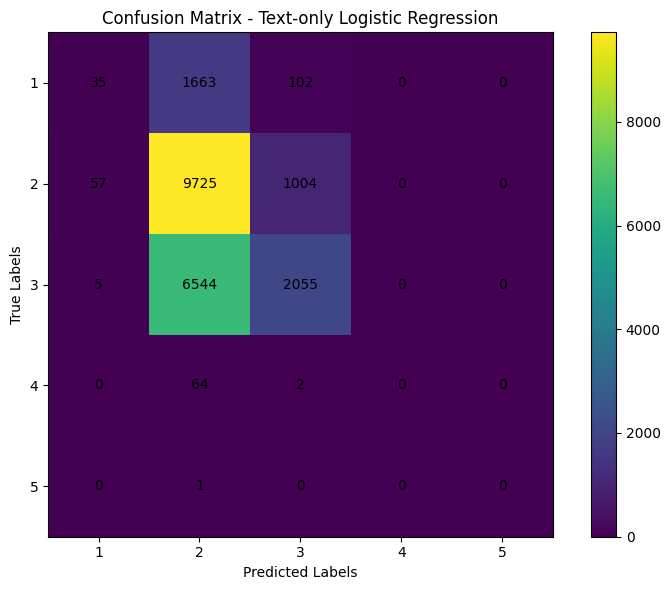

In [14]:
# Import plotting libraries
import matplotlib.pyplot as plt
import numpy as np

# Create the confusion matrix
cm_text = confusion_matrix(y_test_text, y_pred_text)

# Plot the confusion matrix using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(cm_text, interpolation="nearest")
plt.title("Confusion Matrix - Text-only Logistic Regression")
plt.colorbar()

classes = sorted(np.unique(y_test_text))
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add cell values to the plot
for i in range(cm_text.shape[0]):
    for j in range(cm_text.shape[1]):
        plt.text(j, i, str(cm_text[i, j]), ha="center", va="center")

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

## Step 9: Plot ROC curves for the text-only baseline

This step plots multiclass ROC curves for the text-only Logistic Regression baseline
and reports the micro-average and macro-average ROC AUC scores.

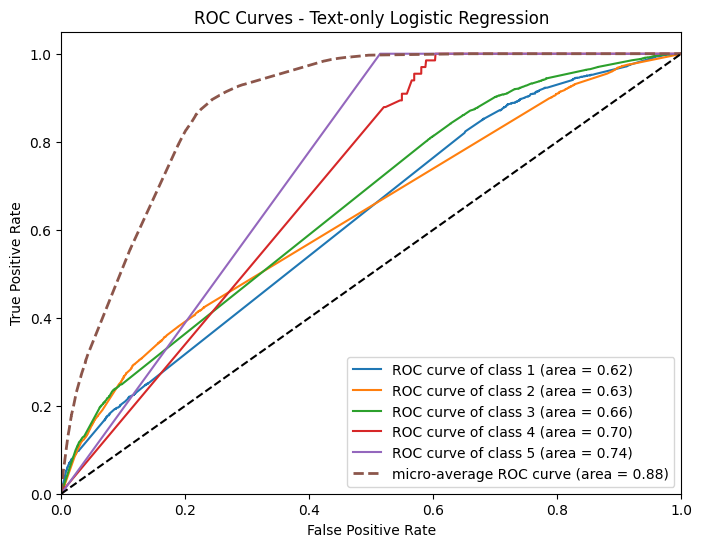

Micro-average ROC AUC: 0.8828772490130015
Macro-average ROC AUC: 0.6713179931628422


In [15]:
# Import additional metrics for ROC analysis
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get probability predictions from the text-only Logistic Regression model
y_prob_text = baseline_model_text.predict_proba(X_test_text)

# Binarise the true labels for multiclass ROC analysis
classes = sorted(y_test_text.unique())
y_test_text_bin = label_binarize(y_test_text, classes=classes)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_text_bin[:, i], y_prob_text[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_text_bin.ravel(), y_prob_text.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average and micro-average ROC AUC scores
roc_auc_macro = roc_auc_score(y_test_text_bin, y_prob_text, average="macro", multi_class="ovr")
roc_auc_micro = roc_auc_score(y_test_text_bin, y_prob_text, average="micro", multi_class="ovr")

# Plot all ROC curves
plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f"ROC curve of class {cls} (area = {roc_auc[i]:.2f})")

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    linewidth=2,
    label=f"micro-average ROC curve (area = {roc_auc_micro:.2f})"
)

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Text-only Logistic Regression")
plt.legend(loc="lower right")
plt.show()

print("Micro-average ROC AUC:", roc_auc_micro)
print("Macro-average ROC AUC:", roc_auc_macro)

## Step 10: Prepare a multi-feature modelling dataset

This step prepares a richer Task 1 dataset using both text and categorical features.

The main text feature is `chief_text_clean_v1`, while the categorical features are:
- `chief_left_class`
- `chief_right_class`
- `chief_text_norm_class`
- `chief_issue_label`
- `clean_action`

In [16]:
# Select the text feature, categorical features, and target label
selected_columns = [
    "chief_text_clean_v1",
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action",
    "acuity"
]

df_model = df[selected_columns].copy()

# Standardise the text column
df_model["chief_text_clean_v1"] = df_model["chief_text_clean_v1"].astype(str).str.strip()

# Standardise categorical columns
categorical_features = [
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action"
]

for col in categorical_features:
    df_model[col] = df_model[col].astype(str).str.strip()

# Standardise and convert the target label
df_model["acuity"] = df_model["acuity"].astype(str).str.strip()
df_model["acuity"] = pd.to_numeric(df_model["acuity"], errors="coerce")

# Remove rows with missing target labels
df_model = df_model.dropna(subset=["acuity"])

# Convert acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Show the prepared dataset
print(df_model.head())
print(df_model["acuity"].value_counts().sort_index())
print(df_model.shape)

          chief_text_clean_v1 chief_left_class chief_right_class  \
0                    s/p fall     symptom_like      symptom_like   
1                    abd pain     symptom_like      symptom_like   
2  cool skin, nausea, malaise   diagnosis_like      symptom_like   
3         dyspnea, chest pain     symptom_like      symptom_like   
4                       brbpr     symptom_like      symptom_like   

  chief_text_norm_class chief_issue_label       clean_action  acuity  
0          symptom_like          retained  keep_symptom_side       2  
1          symptom_like          retained  keep_symptom_side       3  
2            mixed_case          retained  keep_symptom_side       2  
3          symptom_like          retained  keep_symptom_side       2  
4          symptom_like          retained  keep_symptom_side       2  
acuity
1     8998
2    53927
3    43020
4      332
5        7
Name: count, dtype: int64
(106284, 7)


## Step 11: Split the multi-feature dataset

This step divides the dataset into training and testing sets using an 80/20 split.
Stratified sampling is applied to preserve the acuity distribution.

In [6]:
# Define input features and target labels
X = df_model.drop(columns=["acuity"])
y = df_model["acuity"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=16
)

# Display split sizes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 85027
Testing samples: 21257


## Step 12: Build a multi-feature Logistic Regression model

This step builds a Logistic Regression model using both text and categorical features.

The text feature is transformed using TF-IDF, and the categorical features are
encoded using one-hot encoding. The processed features are then combined into
a single modelling pipeline.

In [17]:
# Import additional preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define the text feature and categorical features
text_feature = "chief_text_clean_v1"
categorical_features = [
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action"
]

# Create a preprocessing pipeline for text and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Build the Logistic Regression pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'chief_text_clean_v1'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['chief_left_class',
                                                   'chief_right_class',
                                                   'chief_text_norm_class',
                                                   'chief_issue_label',
                                                   'clean_action'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## Step 13: Evaluate the multi-feature Logistic Regression model

This step evaluates the Logistic Regression model trained with multiple features.
The results will be compared with the earlier text-only baseline.

In [18]:
# Generate predictions from the multi-feature Logistic Regression model
y_pred = baseline_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5831020369760549

Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.02      0.04      1800
           2       0.59      0.76      0.66     10786
           3       0.58      0.48      0.53      8604
           4       0.00      0.00      0.00        66
           5       0.00      0.00      0.00         1

    accuracy                           0.58     21257
   macro avg       0.32      0.25      0.25     21257
weighted avg       0.57      0.58      0.55     21257


Confusion Matrix:
[[  38 1272  490    0    0]
 [  50 8196 2540    0    0]
 [   4 4439 4161    0    0]
 [   0   23   43    0    0]
 [   0    0    1    0    0]]


## Step 14: Calculate training and testing accuracy

This step calculates both training accuracy and testing accuracy for the
multi-feature Logistic Regression model. This helps identify possible overfitting.

In [20]:
# Calculate training and testing accuracy
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.5929528267491503
Test Accuracy: 0.5831020369760549


## Step 15: Compare the text-only and multi-feature Logistic Regression models

This step compares the performance of the text-only Logistic Regression baseline
with the multi-feature Logistic Regression model.

The comparison focuses on:
- training accuracy,
- testing accuracy,
- and the improvement in testing performance after adding more features.

In [21]:
# Calculate training accuracy for the multi-feature Logistic Regression model
y_train_pred_multi = baseline_model.predict(X_train)
train_accuracy_multi = accuracy_score(y_train, y_train_pred_multi)

# Calculate testing accuracy for the multi-feature Logistic Regression model
y_test_pred_multi = baseline_model.predict(X_test)
test_accuracy_multi = accuracy_score(y_test, y_test_pred_multi)

# Compare the text-only and multi-feature Logistic Regression models
comparison_df = pd.DataFrame({
    "Model": [
        "Text-only Logistic Regression",
        "Multi-feature Logistic Regression"
    ],
    "Train Accuracy": [
        train_accuracy_text,
        train_accuracy_multi
    ],
    "Test Accuracy": [
        test_accuracy_text,
        test_accuracy_multi
    ]
})

print(comparison_df)

print("\nTest accuracy improvement:")
print(test_accuracy_multi - test_accuracy_text)

                               Model  Train Accuracy  Test Accuracy
0      Text-only Logistic Regression        0.567808       0.555817
1  Multi-feature Logistic Regression        0.592953       0.583102

Test accuracy improvement:
0.027285129604365577


## Step 16: Interpret the comparison between the text-only and multi-feature Logistic Regression models

The comparison shows that adding the cleaned categorical features improves the performance
of Logistic Regression compared with the text-only baseline.

The text-only Logistic Regression model achieved:
- train accuracy: 0.5678
- test accuracy: 0.5558

The multi-feature Logistic Regression model achieved:
- train accuracy: 0.5930
- test accuracy: 0.5831

This means that the multi-feature model improves the test accuracy by about 0.0273,
which suggests that the additional cleaned categorical features provide useful information
for Task 1 acuity prediction.

However, the improvement is still relatively limited. This suggests that:
- the added features are helpful but not sufficient for a major performance jump,
- the current Task 1 dataset may still have limited predictive information,
- and further improvement may require better feature engineering, parameter tuning,
  or additional structured clinical variables.

## Step 17: Train a multi-feature Decision Tree model

This step trains a Decision Tree classifier using the same multi-feature input setup
as the multi-feature Logistic Regression model.

The purpose is to test whether a tree-based model can make better use of the cleaned
text and categorical features.

In [22]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Build the preprocessing pipeline for text and categorical features
text_feature = "chief_text_clean_v1"
categorical_features = [
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action"
]

preprocessor_dt = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Build the multi-feature Decision Tree pipeline
dt_model_multi = Pipeline([
    ("preprocessor", preprocessor_dt),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=0.0001
    ))
])

# Train the multi-feature Decision Tree model
dt_model_multi.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'chief_text_clean_v1'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['chief_left_class',
                                                   'chief_right_class',
                                                   'chief_text_norm_class',
                                                   'chief_issue_label',
                                                   'clean_action'])])),
                ('clf',
                 DecisionTreeClassifier(ccp_alpha=0.0001, random_state=42))])

## Step 18: Evaluate the multi-feature Decision Tree model

This step evaluates the multi-feature Decision Tree model using accuracy,
classification report, and confusion matrix.

In [23]:
# Generate predictions from the multi-feature Decision Tree model
y_pred_dt_multi = dt_model_multi.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt_multi))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_multi, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_multi))

Accuracy: 0.580138307381098

Classification Report:
              precision    recall  f1-score   support

           1       0.42      0.02      0.04      1800
           2       0.58      0.77      0.66     10786
           3       0.57      0.47      0.52      8604
           4       0.00      0.00      0.00        66
           5       0.00      0.00      0.00         1

    accuracy                           0.58     21257
   macro avg       0.32      0.25      0.24     21257
weighted avg       0.56      0.58      0.55     21257


Confusion Matrix:
[[  39 1282  479    0    0]
 [  47 8264 2475    0    0]
 [   7 4568 4029    0    0]
 [   0   22   44    0    0]
 [   0    0    1    0    0]]


## Step 19: Calculate training and testing accuracy for the multi-feature Decision Tree model

This step calculates both training accuracy and testing accuracy for the
multi-feature Decision Tree model. This helps identify overfitting.

In [25]:
# Calculate training and testing accuracy
y_train_pred_dt_multi = dt_model_multi.predict(X_train)
y_test_pred_dt_multi = dt_model_multi.predict(X_test)

train_accuracy_dt_multi = accuracy_score(y_train, y_train_pred_dt_multi)
test_accuracy_dt_multi = accuracy_score(y_test, y_test_pred_dt_multi)

print("Multi-feature Decision Tree Train Accuracy:", train_accuracy_dt_multi)
print("Multi-feature Decision Tree Test Accuracy:", test_accuracy_dt_multi)

Multi-feature Decision Tree Train Accuracy: 0.5835440507133028
Multi-feature Decision Tree Test Accuracy: 0.580138307381098


## Step 20: Compare the multi-feature Logistic Regression and multi-feature Decision Tree models

This step compares the performance of the multi-feature Logistic Regression model
with the multi-feature Decision Tree model.

The comparison focuses on training accuracy and testing accuracy.

In [26]:
# Build a comparison table for the two multi-feature models
comparison_multi_models_df = pd.DataFrame({
    "Model": [
        "Multi-feature Logistic Regression",
        "Multi-feature Decision Tree"
    ],
    "Train Accuracy": [
        train_accuracy_multi,
        train_accuracy_dt_multi
    ],
    "Test Accuracy": [
        test_accuracy_multi,
        test_accuracy_dt_multi
    ]
})

print(comparison_multi_models_df)

print("\nTest Accuracy Difference (Decision Tree - Logistic Regression):")
print(test_accuracy_dt_multi - test_accuracy_multi)

                               Model  Train Accuracy  Test Accuracy
0  Multi-feature Logistic Regression        0.592953       0.583102
1        Multi-feature Decision Tree        0.583544       0.580138

Test Accuracy Difference (Decision Tree - Logistic Regression):
-0.002963729594956943


## Step 21: Interpretation of the multi-feature Decision Tree results

The multi-feature Decision Tree model achieved a slightly lower test accuracy than the
multi-feature Logistic Regression model.

Results:
- Multi-feature Logistic Regression test accuracy: 0.5831
- Multi-feature Decision Tree test accuracy: 0.5801

This suggests that, on the current Task 1 dataset, adding the cleaned categorical features
does not make Decision Tree outperform Logistic Regression.

A possible explanation is that the current feature representation is still mainly based on
TF-IDF text features and sparse encoded categorical variables. Logistic Regression is often
more stable than a single Decision Tree on this type of data.

Therefore, the current results indicate that the multi-feature Logistic Regression model
remains the stronger model, while the multi-feature Decision Tree model does not provide
an additional performance benefit at this stage.

## Step 21: Train a multi-feature Random Forest model

This step trains a Random Forest classifier using the same multi-feature input setup
as the previous models.

Random Forest is included because it is usually more stable than a single Decision Tree
and may capture more useful feature interactions.

In [27]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Build the preprocessing pipeline for text and categorical features
text_feature = "chief_text_clean_v1"
categorical_features = [
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action"
]

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Build the multi-feature Random Forest pipeline
rf_model_multi = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the multi-feature Random Forest model
rf_model_multi.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'chief_text_clean_v1'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['chief_left_class',
                                                   'chief_right_class',
                                                   'chief_text_norm_class',
                                                   'chief_issue_label',
                                                   'clean_action'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## Step 22: Evaluate the multi-feature Random Forest model

This step evaluates the multi-feature Random Forest model using accuracy,
classification report, and confusion matrix.

In [28]:
# Generate predictions from the multi-feature Random Forest model
y_pred_rf_multi = rf_model_multi.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf_multi))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_multi, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_multi))

Accuracy: 0.5799501340734817

Classification Report:
              precision    recall  f1-score   support

           1       0.32      0.03      0.05      1800
           2       0.59      0.75      0.66     10786
           3       0.57      0.48      0.52      8604
           4       0.00      0.00      0.00        66
           5       0.00      0.00      0.00         1

    accuracy                           0.58     21257
   macro avg       0.30      0.25      0.25     21257
weighted avg       0.56      0.58      0.55     21257


Confusion Matrix:
[[  45 1263  492    0    0]
 [  85 8122 2579    0    0]
 [  10 4432 4161    1    0]
 [   0   23   43    0    0]
 [   0    0    1    0    0]]


## Step 23: Calculate training and testing accuracy for the multi-feature Random Forest model

This step calculates both training accuracy and testing accuracy for the
multi-feature Random Forest model. This helps check whether the model is overfitting.

In [29]:
# Calculate training and testing accuracy
y_train_pred_rf_multi = rf_model_multi.predict(X_train)
y_test_pred_rf_multi = rf_model_multi.predict(X_test)

train_accuracy_rf_multi = accuracy_score(y_train, y_train_pred_rf_multi)
test_accuracy_rf_multi = accuracy_score(y_test, y_test_pred_rf_multi)

print("Multi-feature Random Forest Train Accuracy:", train_accuracy_rf_multi)
print("Multi-feature Random Forest Test Accuracy:", test_accuracy_rf_multi)

Multi-feature Random Forest Train Accuracy: 0.6178508003340115
Multi-feature Random Forest Test Accuracy: 0.5799501340734817


## Step 24: Compare the multi-feature Logistic Regression, Decision Tree, and Random Forest models

This step compares the performance of the three multi-feature models:
Logistic Regression, Decision Tree, and Random Forest.

The comparison focuses on training accuracy and testing accuracy.

In [31]:
# Build a comparison table for the three multi-feature models
comparison_multi_models_df = pd.DataFrame({
    "Model": [
        "Multi-feature Logistic Regression",
        "Multi-feature Decision Tree",
        "Multi-feature Random Forest"
    ],
    "Train Accuracy": [
        train_accuracy_multi,
        train_accuracy_dt_multi,
        train_accuracy_rf_multi
    ],
    "Test Accuracy": [
        test_accuracy_multi,
        test_accuracy_dt_multi,
        test_accuracy_rf_multi
    ]
})

print(comparison_multi_models_df)

print("\nTest Accuracy Difference (Random Forest - Logistic Regression):")
print(test_accuracy_rf_multi - test_accuracy_multi)

                               Model  Train Accuracy  Test Accuracy
0  Multi-feature Logistic Regression        0.592953       0.583102
1        Multi-feature Decision Tree        0.583544       0.580138
2        Multi-feature Random Forest        0.617851       0.579950

Test Accuracy Difference (Random Forest - Logistic Regression):
-0.003151902902573167


## Step 25: Interpretation of the multi-feature Random Forest results

The multi-feature Random Forest model achieved a slightly lower test accuracy than the
multi-feature Logistic Regression model.

Results:
- Multi-feature Logistic Regression test accuracy: 0.5831
- Multi-feature Decision Tree test accuracy: 0.5801
- Multi-feature Random Forest test accuracy: 0.5800

Although Random Forest achieved a higher training accuracy, this improvement did not
translate into better testing performance. This suggests that the Random Forest model
fits the training data slightly more strongly, but does not generalise better than
Logistic Regression on the current Task 1 dataset.

Overall, the current results indicate that the multi-feature Logistic Regression model
remains the strongest model among the tested multi-feature baselines.

## Step 26: Train a multi-feature XGBoost model

This step trains an XGBoost classifier using the same multi-feature input setup
as the previous models.

XGBoost is included because it is often stronger than basic tree models and may
capture more complex feature interactions.

In [32]:
# Import XGBoost and LabelEncoder
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Encode the target labels for XGBoost
label_encoder_multi = LabelEncoder()
y_train_xgb_multi = label_encoder_multi.fit_transform(y_train)
y_test_xgb_multi = label_encoder_multi.transform(y_test)

# Build the preprocessing pipeline for text and categorical features
text_feature = "chief_text_clean_v1"
categorical_features = [
    "chief_left_class",
    "chief_right_class",
    "chief_text_norm_class",
    "chief_issue_label",
    "clean_action"
]

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Build the multi-feature XGBoost pipeline
xgb_model_multi = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("clf", xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=len(label_encoder_multi.classes_),
        eval_metric="mlogloss",
        random_state=42
    ))
])

# Train the multi-feature XGBoost model
xgb_model_multi.fit(X_train, y_train_xgb_multi)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'chief_text_clean_v1'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['chief_left_class',
                                                   'chief_right_class',
                                                   'chief_text_norm_class',
                                                   'chief_issue_label',
                                                   'clean_action'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=N...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None, num_class=5,
                               num_parallel_tree=None, ...))])

## Step 27: Evaluate the multi-feature XGBoost model

This step evaluates the multi-feature XGBoost model using accuracy,
classification report, and confusion matrix.

In [33]:
# Generate encoded predictions from the multi-feature XGBoost model
y_pred_xgb_multi_encoded = xgb_model_multi.predict(X_test)

# Convert encoded predictions back to the original acuity labels
y_pred_xgb_multi = label_encoder_multi.inverse_transform(y_pred_xgb_multi_encoded)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_multi))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_multi, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_multi))

Accuracy: 0.587335936397422

Classification Report:
              precision    recall  f1-score   support

           1       0.42      0.02      0.04      1800
           2       0.61      0.69      0.65     10786
           3       0.56      0.57      0.56      8604
           4       0.00      0.00      0.00        66
           5       0.00      0.00      0.00         1

    accuracy                           0.59     21257
   macro avg       0.32      0.26      0.25     21257
weighted avg       0.57      0.59      0.56     21257


Confusion Matrix:
[[  42 1081  677    0    0]
 [  54 7496 3236    0    0]
 [   5 3652 4947    0    0]
 [   0   18   48    0    0]
 [   0    0    1    0    0]]


## Step 28: Calculate training and testing accuracy for the multi-feature XGBoost model

This step calculates both training accuracy and testing accuracy for the
multi-feature XGBoost model. This helps check whether the model is overfitting.

In [34]:
# Generate predictions for the training and testing sets
y_train_pred_xgb_multi_encoded = xgb_model_multi.predict(X_train)
y_test_pred_xgb_multi_encoded = xgb_model_multi.predict(X_test)

# Convert encoded predictions back to the original acuity labels
y_train_pred_xgb_multi = label_encoder_multi.inverse_transform(y_train_pred_xgb_multi_encoded)
y_test_pred_xgb_multi = label_encoder_multi.inverse_transform(y_test_pred_xgb_multi_encoded)

# Calculate training and testing accuracy
train_accuracy_xgb_multi = accuracy_score(y_train, y_train_pred_xgb_multi)
test_accuracy_xgb_multi = accuracy_score(y_test, y_test_pred_xgb_multi)

print("Multi-feature XGBoost Train Accuracy:", train_accuracy_xgb_multi)
print("Multi-feature XGBoost Test Accuracy:", test_accuracy_xgb_multi)

Multi-feature XGBoost Train Accuracy: 0.5925294318275371
Multi-feature XGBoost Test Accuracy: 0.587335936397422


## Step 29: Compare all multi-feature models

This step compares the performance of all multi-feature models:
Logistic Regression, Decision Tree, Random Forest, and XGBoost.

The comparison focuses on training accuracy and testing accuracy.

In [35]:
# Build a comparison table for all multi-feature models
comparison_all_multi_df = pd.DataFrame({
    "Model": [
        "Multi-feature Logistic Regression",
        "Multi-feature Decision Tree",
        "Multi-feature Random Forest",
        "Multi-feature XGBoost"
    ],
    "Train Accuracy": [
        train_accuracy_multi,
        train_accuracy_dt_multi,
        train_accuracy_rf_multi,
        train_accuracy_xgb_multi
    ],
    "Test Accuracy": [
        test_accuracy_multi,
        test_accuracy_dt_multi,
        test_accuracy_rf_multi,
        test_accuracy_xgb_multi
    ]
})

print(comparison_all_multi_df)

print("\nTest Accuracy Difference (XGBoost - Logistic Regression):")
print(test_accuracy_xgb_multi - test_accuracy_multi)

                               Model  Train Accuracy  Test Accuracy
0  Multi-feature Logistic Regression        0.592953       0.583102
1        Multi-feature Decision Tree        0.583544       0.580138
2        Multi-feature Random Forest        0.617851       0.579950
3              Multi-feature XGBoost        0.592529       0.587336

Test Accuracy Difference (XGBoost - Logistic Regression):
0.004233899421367093


## Step 30: Interpretation of the multi-feature XGBoost results

The multi-feature XGBoost model achieved the best test accuracy among all tested
multi-feature models.

Results:
- Multi-feature Logistic Regression test accuracy: 0.5831
- Multi-feature Decision Tree test accuracy: 0.5801
- Multi-feature Random Forest test accuracy: 0.5800
- Multi-feature XGBoost test accuracy: 0.5873

This shows that XGBoost makes slightly better use of the current multi-feature Task 1
dataset than the other tested models.

However, the improvement over Logistic Regression is still relatively small.
This suggests that the current feature set provides some additional predictive value,
but the overall information available in the dataset remains limited.

The small gap between training accuracy and testing accuracy also suggests that the
multi-feature XGBoost model generalises reasonably well and does not show strong overfitting.

Therefore, among the current multi-feature models, XGBoost is selected as the strongest model.

## Step 31: Summarise all final Task 1 results

This step summarises the main Task 1 modelling results, including the text-only baseline
and all tested multi-feature models.

In [36]:
# Build a final summary table for all main Task 1 models
final_task1_results_df = pd.DataFrame({
    "Model": [
        "Text-only Logistic Regression",
        "Multi-feature Logistic Regression",
        "Multi-feature Decision Tree",
        "Multi-feature Random Forest",
        "Multi-feature XGBoost"
    ],
    "Train Accuracy": [
        train_accuracy_text,
        train_accuracy_multi,
        train_accuracy_dt_multi,
        train_accuracy_rf_multi,
        train_accuracy_xgb_multi
    ],
    "Test Accuracy": [
        test_accuracy_text,
        test_accuracy_multi,
        test_accuracy_dt_multi,
        test_accuracy_rf_multi,
        test_accuracy_xgb_multi
    ]
})

# Sort the final summary table by test accuracy
final_task1_results_df = final_task1_results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print(final_task1_results_df)

                               Model  Train Accuracy  Test Accuracy
0              Multi-feature XGBoost        0.592529       0.587336
1  Multi-feature Logistic Regression        0.592953       0.583102
2        Multi-feature Decision Tree        0.583544       0.580138
3        Multi-feature Random Forest        0.617851       0.579950
4      Text-only Logistic Regression        0.567808       0.555817


## Step 32: Final interpretation of Task 1 results

The Task 1 experiments show that adding the cleaned categorical features improves
performance compared with the text-only baseline.

Among all tested models:
- the text-only Logistic Regression baseline achieved lower performance,
- the multi-feature models performed better overall,
- and the multi-feature XGBoost model achieved the best test accuracy.

This suggests that the additional cleaned categorical features provide useful information
for acuity prediction, although the improvement is still limited.

Therefore, the current Task 1 results indicate that:
- the current dataset contains some useful predictive signal,
- richer multi-feature modelling is better than the text-only baseline,
- XGBoost is the strongest model under the current feature setup,
- but the overall performance is still constrained by limited feature richness and class imbalance.